In [1]:
import numpy as np

data = np.load("output/paired_ratio_0.8.npz", allow_pickle=True)

# See all keys
print("Keys:", list(data.keys()))

# Check shapes and dtypes
for key in data.keys():
    arr = data[key]
    print(f"  {key:15s} shape={str(arr.shape):20s} dtype={arr.dtype}")

# Preview first sample
print("\nFirst input window:", data["input"][0][:10], "...")
print("First target window:", data["target"][0][:10], "...")
print("Depth ratio:", data["depth_ratio"])
print("First few chroms:", data["chroms"][:5])
print("First few starts:", data["starts"][:5])

Keys: ['input', 'target', 'depth_ratio', 'chroms', 'starts']
  input           shape=(617617, 400)        dtype=float32
  target          shape=(617617, 400)        dtype=float32
  depth_ratio     shape=()                   dtype=float32
  chroms          shape=(617617,)            dtype=<U5
  starts          shape=(617617,)            dtype=int64

First input window: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] ...
First target window: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] ...
Depth ratio: 0.8
First few chroms: ['chr1' 'chr1' 'chr1' 'chr1' 'chr1']
First few starts: [    0  5000 10000 15000 20000]


In [3]:

from CNN import DeepMeripCNN
import torch
m = DeepMeripCNN(feature_dim=1, d_model=128, num_res_blocks=6)
x = torch.randn(2, 400, 1)
out = m(x)
print(type(out))
if isinstance(out, tuple):
    print(f'Tuple of {len(out)} elements')
    for i, o in enumerate(out):
        print(f'  [{i}] shape={o.shape}')
else:
    print(f'Single tensor, shape={out.shape}')


<class 'torch.Tensor'>
Single tensor, shape=torch.Size([2, 400])


In [4]:
import numpy as np
data = np.load("0_5_ds.npz")
print(data.files)

['X', 'Y', 'depth', 'category', 'sample_id', 'chrom', 'start_bp', 'end_bp']


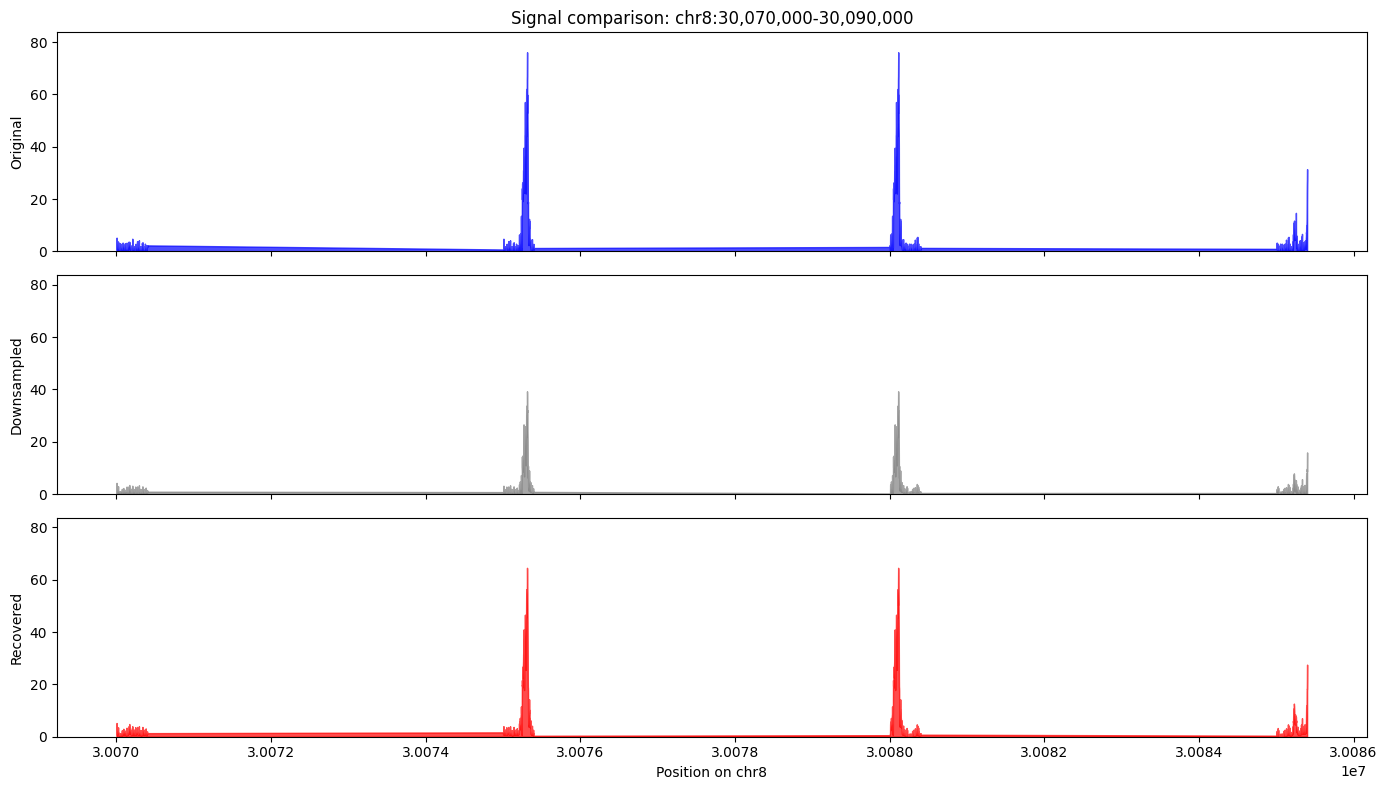

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load the three bedGraph files for the region
def load_bedgraph(path, chrom, start, end):
    positions, values = [], []
    with open(path) as f:
        for line in f:
            if line.startswith("track"):
                continue
            parts = line.strip().split("\t")
            c, s, e, v = parts[0], int(parts[1]), int(parts[2]), float(parts[3])
            if c == chrom and s >= start and e <= end:
                positions.append(s)
                values.append(v)
    return np.array(positions), np.array(values)

chrom = "chr8"
start, end = 30070000, 30090000

pos_o, val_o = load_bedgraph("peakcalling/original.sorted.bg", chrom, start, end)
pos_d, val_d = load_bedgraph("peakcalling/downsampled.sorted.bg", chrom, start, end)
pos_r, val_r = load_bedgraph("peakcalling/recovered.sorted.bg", chrom, start, end)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].fill_between(pos_o, val_o, alpha=0.7, color="blue")
axes[0].set_ylabel("Original")
axes[0].set_ylim(0, max(val_o.max(), val_r.max()) * 1.1)

axes[1].fill_between(pos_d, val_d, alpha=0.7, color="gray")
axes[1].set_ylabel("Downsampled")
axes[1].set_ylim(0, max(val_o.max(), val_r.max()) * 1.1)

axes[2].fill_between(pos_r, val_r, alpha=0.7, color="red")
axes[2].set_ylabel("Recovered")
axes[2].set_ylim(0, max(val_o.max(), val_r.max()) * 1.1)

axes[2].set_xlabel(f"Position on {chrom}")
axes[0].set_title(f"Signal comparison: {chrom}:{start:,}-{end:,}")
plt.tight_layout()
plt.savefig("peakcalling/signal_comparison.png", dpi=150)
plt.show()

In [2]:
import numpy as np
data = np.load("0_5_ds.npz", allow_pickle=False)
print(data.files)

['X', 'Y', 'depth', 'category', 'sample_id', 'chrom', 'start_bp', 'end_bp']


In [3]:
import numpy as np
data = np.load("0_5_ds.npz", allow_pickle=False)
print("X shape:", data["X"].shape)
print("Y shape:", data["Y"].shape)

X shape: (2323920, 1, 400)
Y shape: (2323920, 1, 400)
